In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d

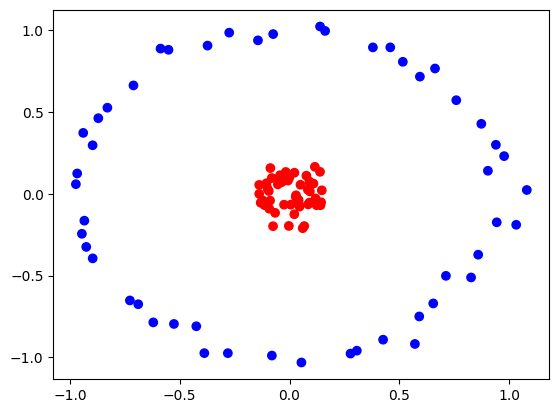

In [43]:
from sklearn.datasets import make_circles
X,y=make_circles(n_samples=100,factor=0.1,noise=0.05)
plt.scatter(X[:,0],X[:,1],c=y,cmap='bwr')


In [44]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2, random_state=2)

In [45]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.45

In [46]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_3041/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


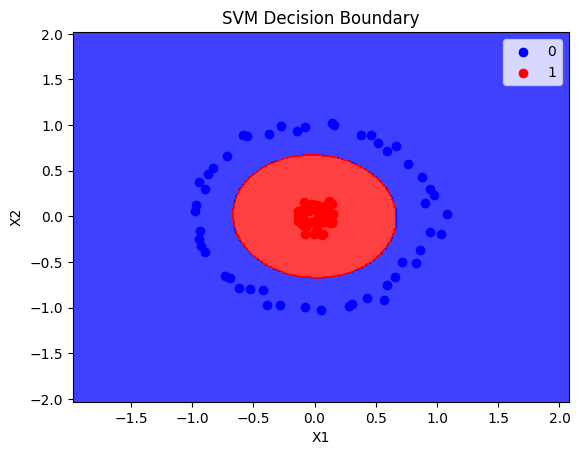

In [48]:
plot_decision_boundary(X, y, classifier)

In [54]:
def plot_3d_plot (X,y):
  r=np.exp(-(X**2).sum(1))
  ax=plt.subplot(projection='3d')
  ax.scatter3D(X[:,0],X[:,1],r,c=y,s=100,cmap='bwr')
  ax.set_xlabel='x'
  ax.set_zlabel='z'
  ax.set_ylabel='y'
  return ax

<Axes3D: >

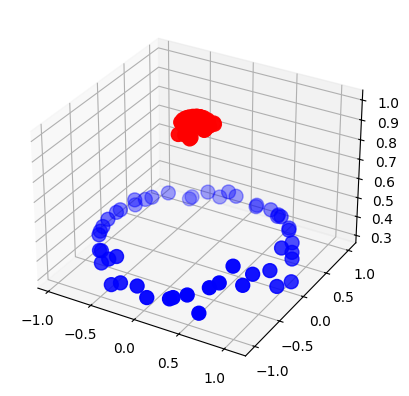

In [55]:
plot_3d_plot(X,y)

In [56]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [57]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_3041/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


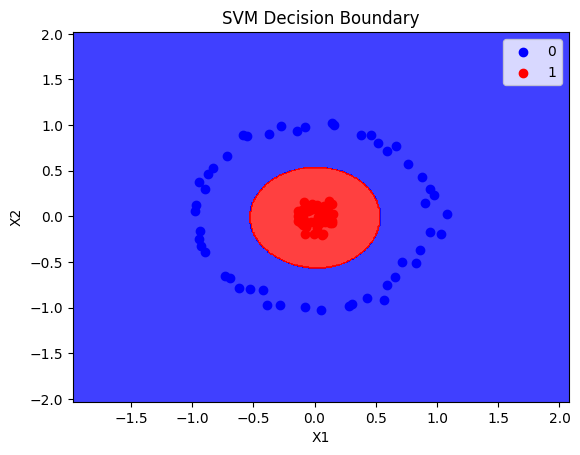

In [58]:

plot_decision_boundary(X, y, rbf_classifier)

/tmp/ipykernel_3041/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


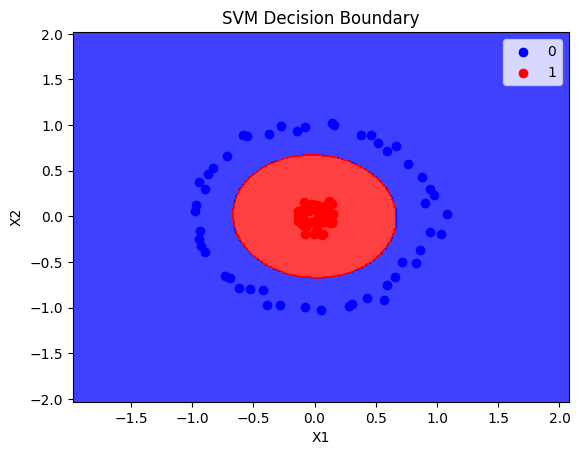

In [62]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)


plot_decision_boundary(X, y, poly_classifier)

In [63]:
accuracy_score(y_test, y_pred)

1.0

In [64]:
X

array([[-4.33928540e-02,  1.14126166e-01],
       [-1.71489939e-02,  1.33999992e-01],
       [ 9.39472115e-02,  5.40943156e-02],
       [-6.20694159e-01, -7.86211804e-01],
       [-5.87515305e-01,  8.88681945e-01],
       [-3.54142509e-02,  7.16715096e-02],
       [ 2.17315432e-02, -1.24465994e-01],
       [ 3.06582979e-01, -9.59242128e-01],
       [-7.28166166e-03,  8.12641028e-02],
       [ 2.22203788e-02,  1.29341070e-01],
       [-7.45586129e-02,  9.77425467e-01],
       [-1.14184119e-01, -6.90714642e-02],
       [-7.50951169e-02, -1.97732555e-01],
       [-2.80924477e-01, -9.74394634e-01],
       [-8.29690539e-01,  5.27027892e-01],
       [ 1.38842517e-01,  1.34900331e-01],
       [-1.31578683e-01, -5.41732460e-02],
       [-7.27190764e-01, -6.52010344e-01],
       [ 9.03557855e-01,  1.41312565e-01],
       [ 4.56679010e-02, -7.79788780e-02],
       [-8.04109336e-02, -9.89070262e-01],
       [-1.38089528e-01,  1.45217868e-04],
       [-8.07292806e-02,  9.68837135e-02],
       [ 5.

In [73]:
X_new=np.exp(-(X**2)) #sum on axis 1
X_new

array([[0.99811883, 0.98705967],
       [0.99970596, 0.98220425],
       [0.99121276, 0.99707808],
       [0.6802729 , 0.53895187],
       [0.70809697, 0.45395573],
       [0.99874662, 0.99487637],
       [0.99952785, 0.9846276 ],
       [0.91028902, 0.39846108],
       [0.99994698, 0.9934179 ],
       [0.99950638, 0.98341004],
       [0.99445644, 0.38467343],
       [0.98704661, 0.9952405 ],
       [0.99437659, 0.96165631],
       [0.92411518, 0.38695576],
       [0.50238607, 0.75747981],
       [0.98090737, 0.98196649],
       [0.98283606, 0.99706956],
       [0.58930794, 0.65369298],
       [0.44201264, 0.98022882],
       [0.99791662, 0.99393774],
       [0.99355494, 0.37596471],
       [0.98111194, 0.99999998],
       [0.99350397, 0.99065746],
       [0.76619679, 0.52069737],
       [0.99937656, 0.99562213],
       [0.41345121, 0.87013711],
       [0.62188946, 0.63400338],
       [0.97864683, 0.99952854],
       [0.99551106, 0.96194188],
       [0.60200707, 0.7776615 ],
       [0.

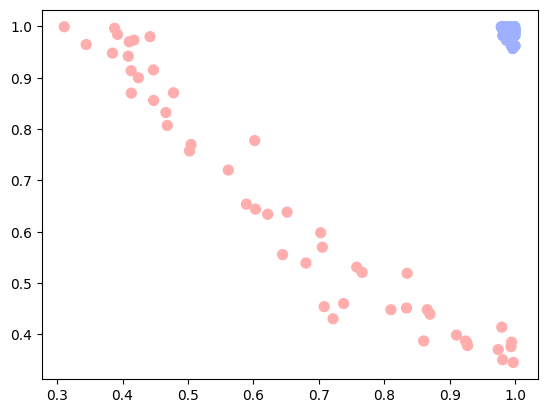

In [80]:
plt.scatter(X_new[:, 0], X_new[:, 1], c=y, s=50, cmap='berlin_r')